# Домашнее задание "Варианционные автоэнкодеры"

В этом домашнем задании вам предстоит реализовать несколько версий автоэнкодера для работы с изображениями.

Вы научитесь добавлять улыбку на фотографии людей, изменяя их исходное выражение лица с помощью обученной модели. А также, обучите ваш автоэнкодер генерировать изображения рукописных цифр.

# Часть 1. Vanilla Autoencoder (10 баллов)

## 1.1. Подготовка данных (1 балл)


Перед тем, как начинать работу с моделями нужно подготовить данные.

In [1]:
import os
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import skimage.io
from skimage.transform import resize
import imageio
from PIL import Image
import kagglehub

%matplotlib inline

RANDOM_STATE = 42

В этом задании вам предстоить работать с датасетом [LFW (Labeled Faces in the Wild)](https://datasets.activeloop.ai/docs/ml/datasets/lfw-dataset/#:~:text=What%20is%20LFW%20Dataset%3F,commercial%20algorithms%20prior%20to%20release).

In [2]:
# Скачиваем картинки
images_path = kagglehub.dataset_download("jessicali9530/lfw-dataset")
print("Path to dataset files:", images_path)

Path to dataset files: /kaggle/input/datasets/jessicali9530/lfw-dataset


In [3]:
# Скачиваем атрибуты
attrs_path = kagglehub.dataset_download("averkij/lfw-attributes")
print("Path to dataset files:", attrs_path)

Path to dataset files: /kaggle/input/datasets/averkij/lfw-attributes


In [4]:
# DATASET_PATH ="/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/"
# ATTRIBUTES_PATH = "/kaggle/input/lfw-attributes/lfw_attributes.txt"
DATASET_PATH = "/kaggle/input/datasets/jessicali9530/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/"
ATTRIBUTES_PATH = "/kaggle/input/datasets/averkij/lfw-attributes/lfw_attributes.txt"

In [5]:
def fetch_dataset(dx=80, dy=80, dimx=45, dimy=45):

    df_attrs = pd.read_csv(ATTRIBUTES_PATH, sep='\t', skiprows=1,)
    df_attrs = pd.DataFrame(df_attrs.iloc[:, :-1].values, columns = df_attrs.columns[1:])

    photo_ids = []
    for dirpath, dirnames, filenames in os.walk(DATASET_PATH):
        for fname in filenames:
            if fname.endswith(".jpg"):
                fpath = os.path.join(dirpath, fname)
                photo_id = fname[:-4].replace('_', ' ').split()
                person_id = ' '.join(photo_id[:-1])
                photo_number = int(photo_id[-1])
                photo_ids.append({'person': person_id,'imagenum': photo_number, 'photo_path': fpath})

    photo_ids = pd.DataFrame(photo_ids)
    df = pd.merge(df_attrs,photo_ids,on=('person', 'imagenum'))

    assert len(df) == len(df_attrs), "Потеряны данные при объединении датафреймов!"

    images = df['photo_path'].apply(imageio.imread)\
                                .apply(lambda img:img[dy:-dy, dx:-dx])\
                                .apply(lambda img: np.array(Image.fromarray(img).resize([dimx, dimy])) )

    images = np.stack(images.values).astype('uint8')
    attrs = df.drop(["photo_path","person","imagenum"],axis=1)

    return images, attrs

In [6]:
# Обратите внимание, что датасет представляет собой не только картинки, но и атрибуты
# Атрибуты понадобятся в конце этого задания

images, attrs = fetch_dataset()

In [7]:
attrs.columns

Index(['Male', 'Asian', 'White', 'Black', 'Baby', 'Child', 'Youth',
       'Middle Aged', 'Senior', 'Black Hair', 'Blond Hair', 'Brown Hair',
       'Bald', 'No Eyewear', 'Eyeglasses', 'Sunglasses', 'Mustache', 'Smiling',
       'Frowning', 'Chubby', 'Blurry', 'Harsh Lighting', 'Flash',
       'Soft Lighting', 'Outdoor', 'Curly Hair', 'Wavy Hair', 'Straight Hair',
       'Receding Hairline', 'Bangs', 'Sideburns', 'Fully Visible Forehead',
       'Partially Visible Forehead', 'Obstructed Forehead', 'Bushy Eyebrows',
       'Arched Eyebrows', 'Narrow Eyes', 'Eyes Open', 'Big Nose',
       'Pointy Nose', 'Big Lips', 'Mouth Closed', 'Mouth Slightly Open',
       'Mouth Wide Open', 'Teeth Not Visible', 'No Beard', 'Goatee',
       'Round Jaw', 'Double Chin', 'Wearing Hat', 'Oval Face', 'Square Face',
       'Round Face', 'Color Photo', 'Posed Photo', 'Attractive Man',
       'Attractive Woman', 'Indian', 'Gray Hair', 'Bags Under Eyes',
       'Heavy Makeup', 'Rosy Cheeks', 'Shiny Skin', 'Pa


Разбейте датасет изображений и атрибутов на train и val, выведите несколько картинок в output, чтобы посмотреть, как они выглядят, и приведите картинки к тензорам pytorch, чтобы можно было скормить их сети:

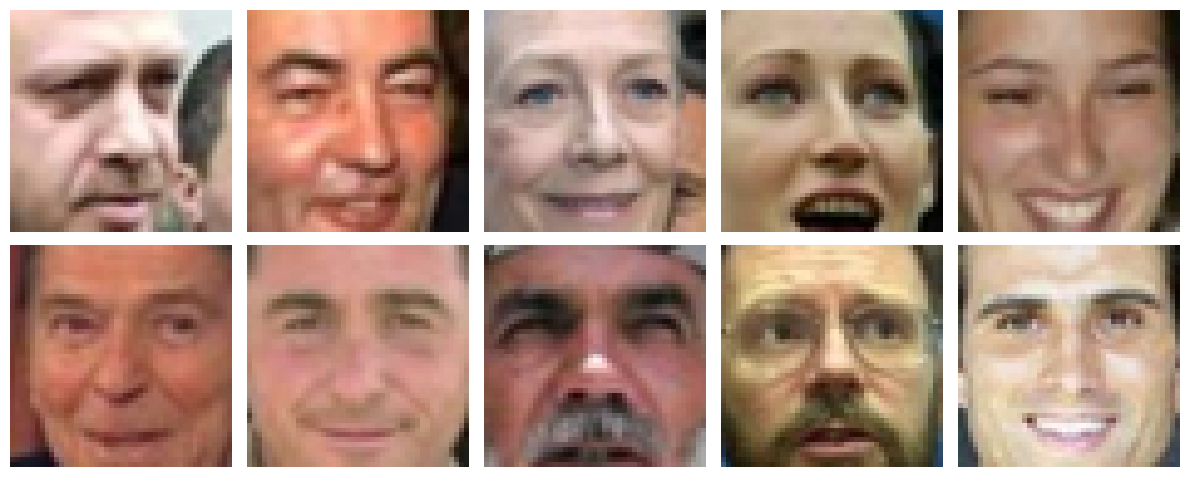

X_train shape: torch.Size([10514, 3, 45, 45])
X_val shape: torch.Size([2629, 3, 45, 45])
attrs_train_tensor shape: torch.Size([10514, 73])
attrs_val shape: (2629, 73)


In [8]:
# train / val split
X_train, X_val, attrs_train, attrs_val = train_test_split(
    images, attrs, test_size=0.2, random_state=RANDOM_STATE
)

attrs_train = attrs_train.reset_index(drop=True)
attrs_val = attrs_val.reset_index(drop=True)

# visualize samples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i])
    ax.axis('off')

plt.tight_layout()
plt.show()

# конвертируем в тензоры
X_train = torch.tensor(X_train, dtype=torch.float32).permute(0, 3, 1, 2) / 255.
X_val = torch.tensor(X_val, dtype=torch.float32).permute(0, 3, 1, 2) / 255.
attrs_train_tensor = torch.tensor(attrs_train.astype(np.float32).values, dtype=torch.float32)
attrs_val_tensor = torch.tensor(attrs_val.astype(np.float32).values, dtype=torch.float32)

# выводим статистику
print(f'X_train shape: {X_train.shape}')
print(f'X_val shape: {X_val.shape}')
print(f'attrs_train_tensor shape: {attrs_train_tensor.shape}')
print(f'attrs_val shape: {attrs_val.shape}')

## 1.2. Архитектура модели (2 балла)
В этом разделе вы напишите и обучите обычный автоэнкодер.


In [9]:
dim_code = 128 # выберите размер латентного вектора

Реализуем autoencoder. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Экспериментируйте!

In [10]:
class Autoencoder(nn.Module):
    def __init__(self, dim_code=128):
        # <определите архитектуры encoder и decoder>
        super(Autoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten()
        )
        self.fc_enc = nn.Linear(128 * 6 * 6, dim_code)

        # Decoder
        self.fc_dec = nn.Linear(dim_code, 128 * 6 * 6)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (128, 6, 6)),
            nn.ConvTranspose2d(
                128, 64, kernel_size=3,
                stride=2, padding=1, output_padding=1
            ),
            nn.ReLU(),
            nn.ConvTranspose2d(
                64, 32, kernel_size=3,
                stride=2, padding=1, output_padding=1
            ),
            nn.ReLU(),
            nn.ConvTranspose2d(
                32, 3, kernel_size=3,
                stride=2, padding=1, output_padding=0
            ),
            nn.Sigmoid()
        )

    def forward(self, x):
        # реализуйте forward проход автоэнкодера
        # в качестве возвращаемых переменных -- латентное представление картинки (latent_code)
        # и полученная реконструкция изображения (reconstruction)
        latent_code = self.fc_enc(self.encoder(x))
        x = self.fc_dec(latent_code)
        reconstruction = self.decoder(x)
        reconstruction = F.interpolate(reconstruction, size=(45, 45), mode='bilinear', align_corners=False)
        #reconstruction = reconstruction[:, :, :45, :45]
        return reconstruction, latent_code

In [11]:
# подключаем gpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

criterion = nn.MSELoss() # <loss>

model_autoencoder = Autoencoder(dim_code=dim_code).to(device)

optimizer = optim.Adam(model_autoencoder.parameters(), lr=1e-3) # <Ваш любимый оптимизатор>


Using device: cuda


## 1.3 Обучение (2 балла)

Осталось написать код обучения автоэнкодера. При этом было бы неплохо в процессе иногда смотреть, как автоэнкодер реконструирует изображения на данном этапе обучения. Наример, после каждой эпохи (прогона train выборки через автоэнкодер) можно смотреть, какие реконструкции получились для каких-то изображений val выборки.

А, ну еще было бы неплохо выводить графики train и val лоссов в процессе тренировки =)

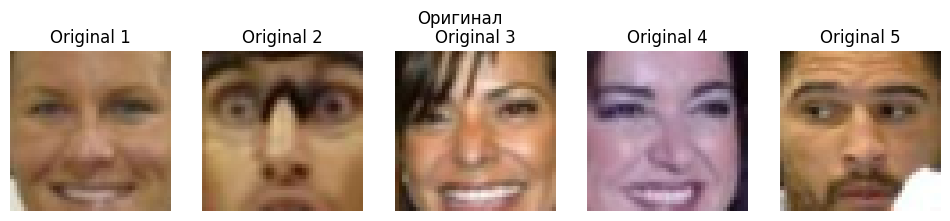

Новая лучшая модель Val Loss: 0.0101
Epoch [1/15] Train Loss: 0.0211 Val Loss: 0.0101


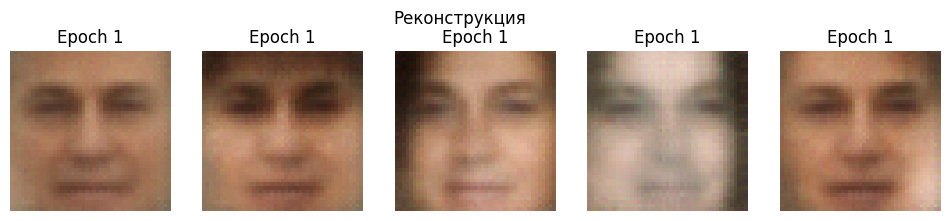

Новая лучшая модель Val Loss: 0.0068
Epoch [2/15] Train Loss: 0.0080 Val Loss: 0.0068


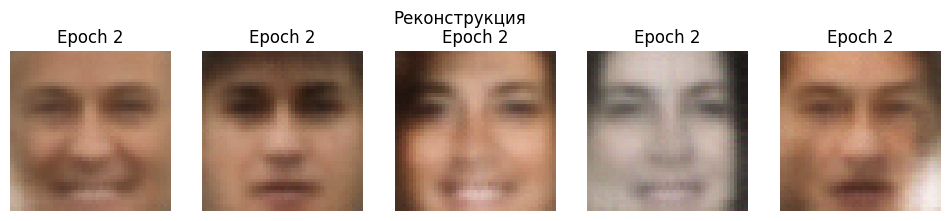

Новая лучшая модель Val Loss: 0.0054
Epoch [3/15] Train Loss: 0.0060 Val Loss: 0.0054


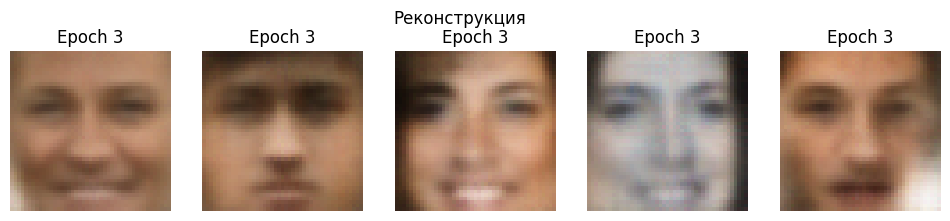

Новая лучшая модель Val Loss: 0.0047
Epoch [4/15] Train Loss: 0.0048 Val Loss: 0.0047


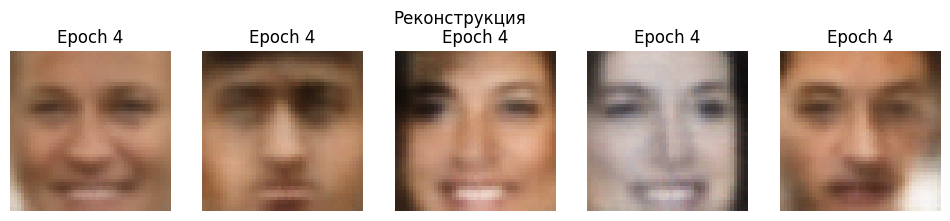

Новая лучшая модель Val Loss: 0.0040
Epoch [5/15] Train Loss: 0.0041 Val Loss: 0.0040


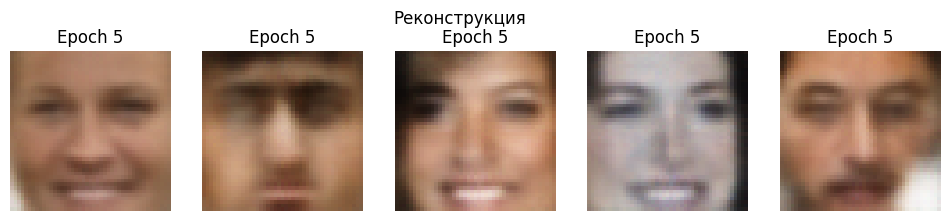

Новая лучшая модель Val Loss: 0.0035
Epoch [6/15] Train Loss: 0.0037 Val Loss: 0.0035


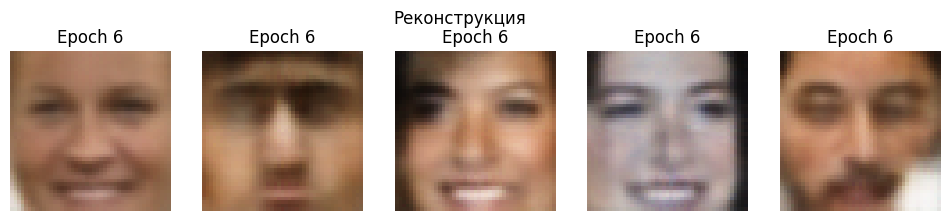

Новая лучшая модель Val Loss: 0.0032
Epoch [7/15] Train Loss: 0.0032 Val Loss: 0.0032


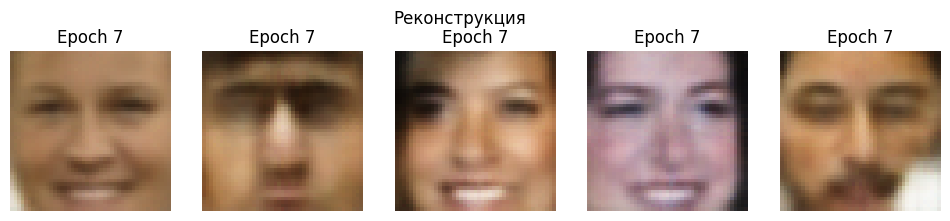

Новая лучшая модель Val Loss: 0.0029
Epoch [8/15] Train Loss: 0.0030 Val Loss: 0.0029


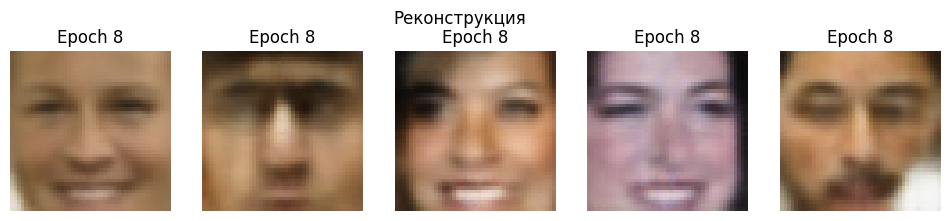

Новая лучшая модель Val Loss: 0.0028
Epoch [9/15] Train Loss: 0.0028 Val Loss: 0.0028


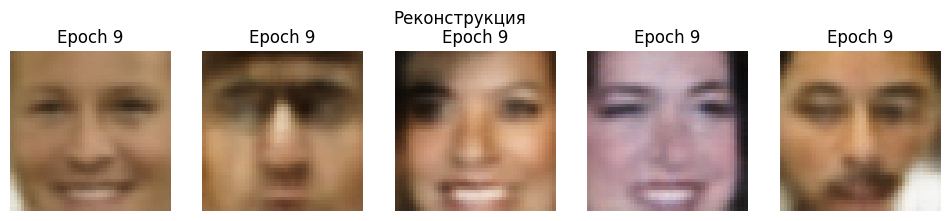

Новая лучшая модель Val Loss: 0.0026
Epoch [10/15] Train Loss: 0.0026 Val Loss: 0.0026


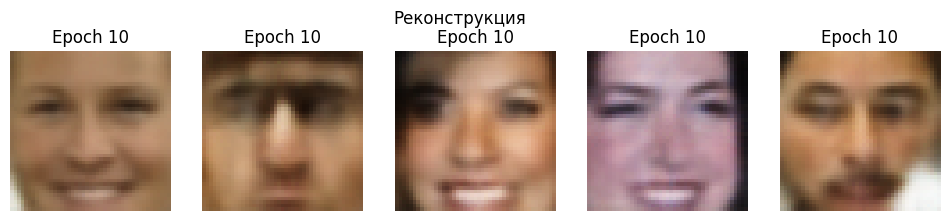

Новая лучшая модель Val Loss: 0.0025
Epoch [11/15] Train Loss: 0.0025 Val Loss: 0.0025


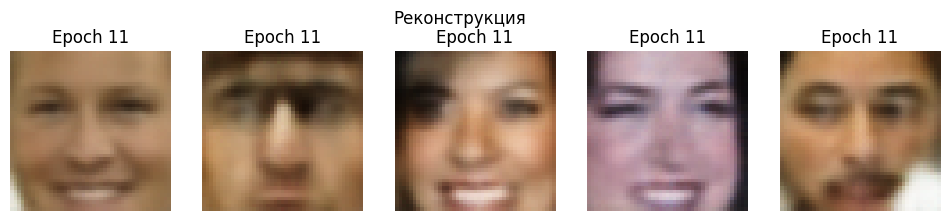

Epoch [12/15] Train Loss: 0.0024 Val Loss: 0.0031


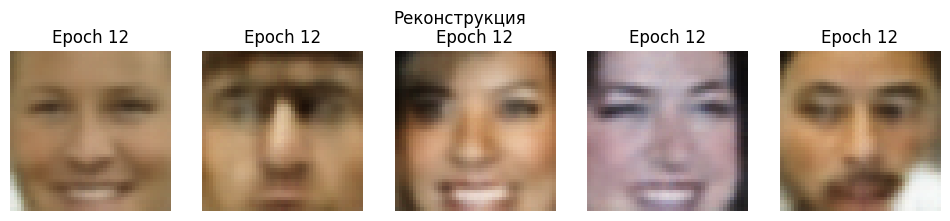

Новая лучшая модель Val Loss: 0.0024
Epoch [13/15] Train Loss: 0.0023 Val Loss: 0.0024


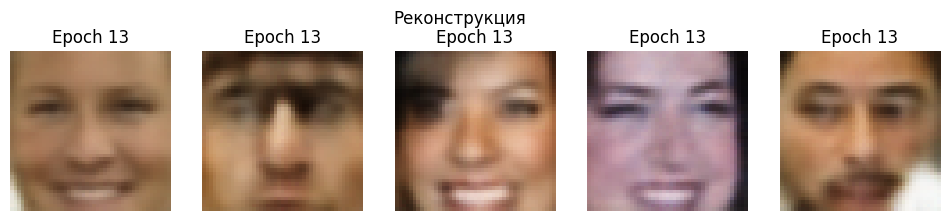

Новая лучшая модель Val Loss: 0.0023
Epoch [14/15] Train Loss: 0.0022 Val Loss: 0.0023


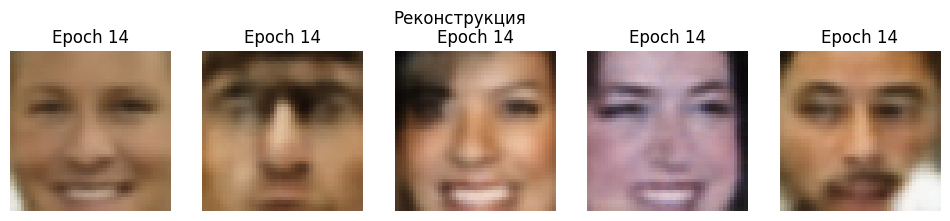

Новая лучшая модель Val Loss: 0.0023
Epoch [15/15] Train Loss: 0.0022 Val Loss: 0.0023


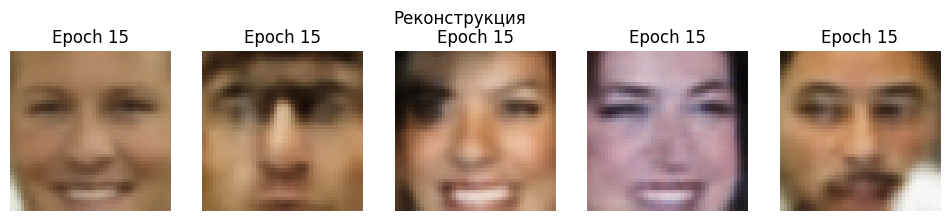

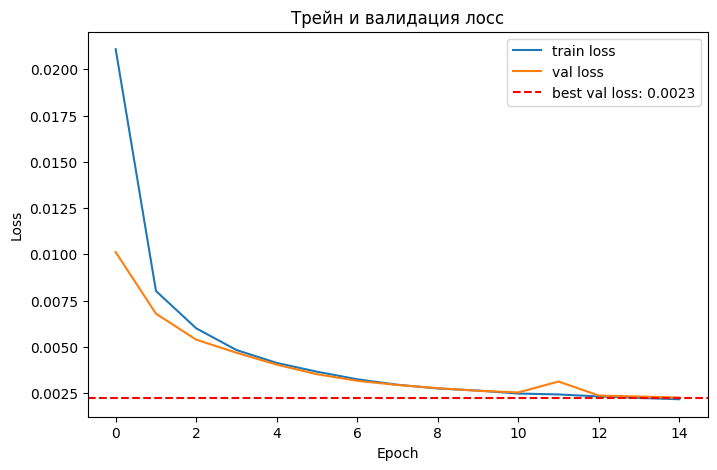

In [12]:
train_loader = DataLoader(X_train, batch_size=64, shuffle=True)
val_loader = DataLoader(X_val, batch_size=64, shuffle=False)

num_epochs = 15
best_val_loss = float('inf')
best_model_state = None
train_losses = []
val_losses = []

# показываем оригинал изображения
with torch.no_grad():
    sample = X_val[:5].to(device)
    sample_cpu = sample.cpu().permute(0, 2, 3, 1).numpy()
    fig, axes = plt.subplots(1, 5, figsize=(12, 2.5))
    for i in range(5):
        axes[i].imshow(sample_cpu[i])
        axes[i].set_title(f'Original {i+1}')
        axes[i].axis('off')
    plt.suptitle('Оригинал')
    plt.show()

for epoch in range(num_epochs):
    # трейн
    model_autoencoder.train()
    train_loss = 0

    for batch in train_loader:
        x = batch.to(device)
        optimizer.zero_grad()
        reconstruction, latent_code = model_autoencoder(x)
        loss = criterion(reconstruction, x)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # валидация
    model_autoencoder.eval()
    val_loss = 0

    with torch.no_grad():
        for batch in val_loader:
            x = batch.to(device)
            reconstruction, latent_code = model_autoencoder(x)
            loss = criterion(reconstruction, x)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    # сохраняем лучшую модель
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model_autoencoder.state_dict())
        print(f'Новая лучшая модель Val Loss: {val_loss:.4f}')
    print(f'Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f} Val Loss: {val_loss:.4f}')

    # отображаем прогресс
    with torch.no_grad():
        reconstruction, _ = model_autoencoder(sample)
        reconstruction_cpu = reconstruction.cpu().permute(0, 2, 3, 1).numpy()
        fig_recon, axes_recon = plt.subplots(1, 5, figsize=(12, 2.5))
        for i in range(5):
            axes_recon[i].imshow(reconstruction_cpu[i])
            axes_recon[i].set_title(f'Epoch {epoch+1}')
            axes_recon[i].axis('off')  
        plt.suptitle('Реконструкция')
        plt.show()

# Отобажаем лосс
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='train loss')
plt.plot(val_losses, label='val loss')
plt.axhline(y=best_val_loss, color='r', linestyle='--', label=f'best val loss: {best_val_loss:.4f}')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Трейн и валидация лосс')
plt.show()


Давайте посмотрим, как наш тренированный автоэнкодер кодирует и восстанавливает картинки:


Загружена лучшая модель с Val Loss: 0.0023


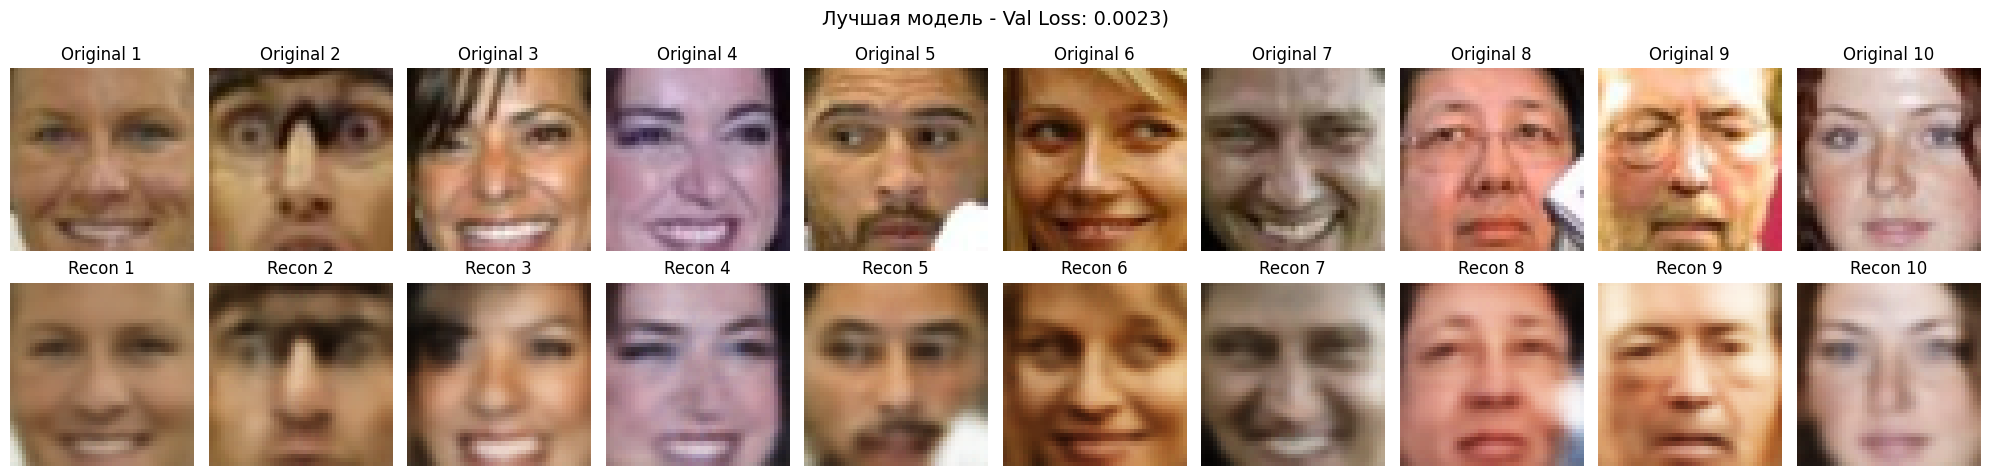

In [13]:
# загружаем лучшую модель
model_autoencoder.load_state_dict(best_model_state)
print(f"\nЗагружена лучшая модель с Val Loss: {best_val_loss:.4f}")


model_autoencoder.eval()
with torch.no_grad():
    sample = X_val[:10].to(device)
    reconstruction, latent_code = model_autoencoder(sample) 
    sample = sample.cpu().permute(0, 2, 3, 1).numpy()
    reconstruction = reconstruction.cpu().permute(0, 2, 3, 1).numpy()

fig, axes = plt.subplots(2, 10, figsize=(20, 5))
for i in range(10):
    axes[0, i].imshow(sample[i])
    axes[0, i].set_title(f'Original {i+1}')
    axes[0, i].axis('off') 
    axes[1, i].imshow(reconstruction[i])
    axes[1, i].set_title(f'Recon {i+1}')
    axes[1, i].axis('off')
plt.suptitle(f'Лучшая модель - Val Loss: {best_val_loss:.4f})', fontsize=14)
plt.tight_layout()
plt.show()


Что вы можете сказать про результат?

Модель обучается нормально, лосс стабильно уменьшается, нет сильного переобучения, картинки потихоньку восстанавливаются.

## 1.4. Sampling (2 балла)

Давайте теперь будем не просто брать картинку, прогонять ее через автоэнкодер и получать реконструкцию, а попробуем создать что-то НОВОЕ!

Давайте возьмем и подсунем декодеру какие-нибудь сгенерированные нами векторы (например, из нормального распределения) и посмотрим на результат реконструкции декодера:

__Подсказка:__ Если вместо лиц у вас выводится непонятно что, попробуйте посмотреть, как выглядят латентные векторы картинок из датасета. Так как в обучении нейронных сетей есть определенная доля рандома, векторы латентного слоя могут быть распределены НЕ как `np.random.randn(25, <latent_space_dim>)`. А чтобы у нас получались лица при запихивании вектора декодеру, вектор должен быть распределен так же, как латентные векторы реальных фоток. Так что в таком случае придется рандом немного подогнать.

Форма латентных векторов: (1000, 128)
Размерность latent space: 128
Среднее: [-0.17594752  0.04910702 -0.05765753 -0.00907606  0.00399755]
Стандартное отклонение: [0.9520101  0.7494792  1.0698997  0.84004724 0.9996016 ]


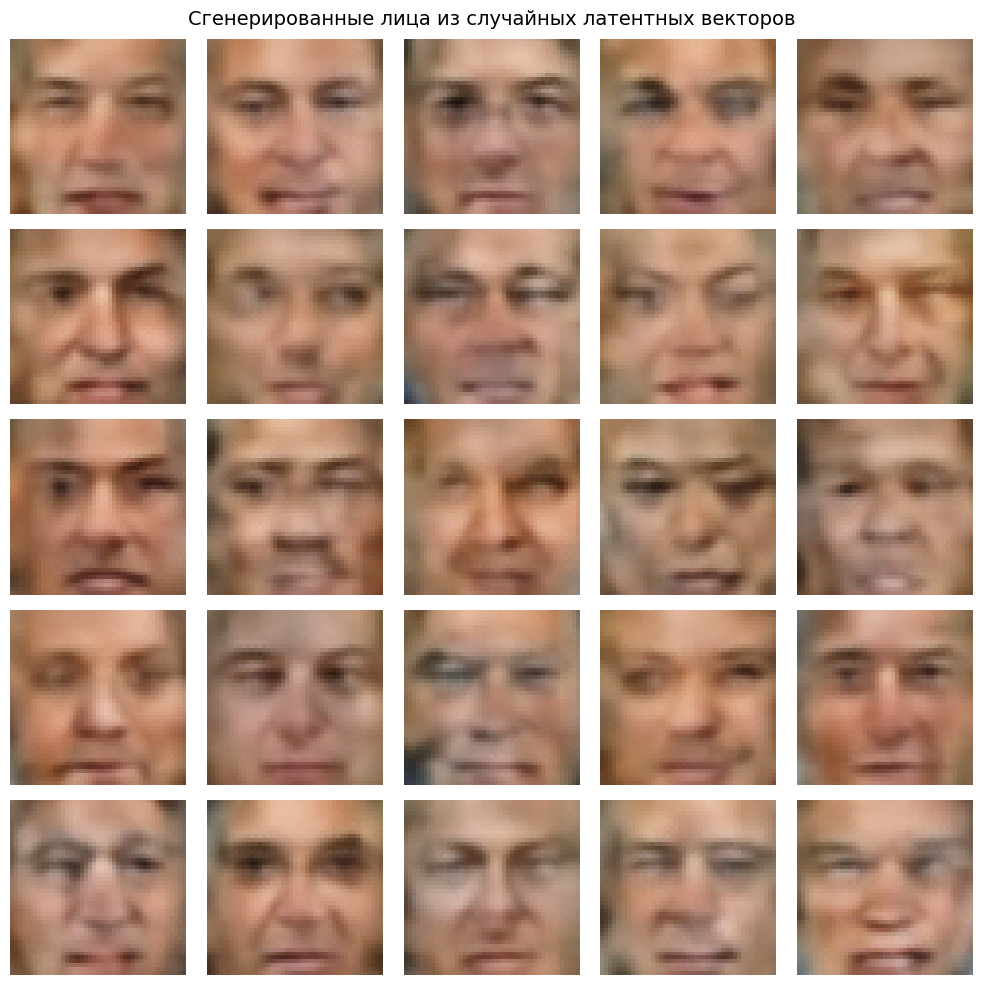

Сгенерированные изображения:
Min значение: 0.061
Max значение: 0.926
Mean значение: 0.507


In [14]:
# получим латентные векторы реальных изображений
model_autoencoder.eval()

with torch.no_grad():
    _, latent_vectors = model_autoencoder(X_train[:1000].to(device))
latent_vectors = latent_vectors.cpu().numpy()
print(f'Форма латентных векторов: {latent_vectors.shape}')

# параметры распределения латентного пространства
z_mean = latent_vectors.mean(axis=0)
z_std = latent_vectors.std(axis=0)

print(f'Размерность latent space: {len(z_mean)}')
print(f'Среднее: {z_mean[:5]}')
print(f'Стандартное отклонение: {z_std[:5]}')

# сгенерируем случайные latent vectors (используем реальную размерность)
num_samples = 25
latent_dim = latent_vectors.shape[1]  # берем реальную размерность
z = np.random.randn(num_samples, latent_dim) * (z_std*0.5) + z_mean
z = torch.tensor(z, dtype=torch.float32).to(device)

# декодирование
with torch.no_grad():
    output = model_autoencoder.fc_dec(z)
    output = model_autoencoder.decoder(output)
    output = output[:, :, :45, :45]

# to numpy
generated_images = output.cpu().permute(0, 2, 3, 1).numpy()

# визуализируем результат
fig, axes = plt.subplots(5, 5, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    # клиппируем значения в диапазон [0,1]
    img = np.clip(generated_images[i], 0, 1)
    ax.imshow(img)
    ax.axis('off')
plt.suptitle('Сгенерированные лица из случайных латентных векторов', fontsize=14)
plt.tight_layout()
plt.show()

# также выведем статистику сгенерированных изображений
print(f'Сгенерированные изображения:')
print(f'Min значение: {generated_images.min():.3f}')
print(f'Max значение: {generated_images.max():.3f}')
print(f'Mean значение: {generated_images.mean():.3f}')

## 1.5 Time to make fun! (3 балла)

Давайте научимся пририсовывать людям улыбки =)

<img src="https://i.imgur.com/tOE9rDK.png" alt="linear" width="700" height="400">

План такой:

1. Нужно выделить "вектор улыбки": для этого нужно из выборки изображений найти несколько (~15) людей с улыбками и столько же без.

Найти людей с улыбками вам поможет файл с атрибутами, скачанный вместе с картинками. В нем указаны имена изображений и присутствубщие атрибуты (улыбки, очки и прочее интересное).

2. Вычислить латентный вектор для всех улыбающихся людей (прогнать их через encoder) и то же для всех грустненьких.

3. Вычислить, собственно, вектор улыбки -- посчитать разность между средним латентным вектором улыбающихся людей и средним латентным вектором грустных людей.

4. А теперь приделаем улыбку грустному человеку: добавим полученный в пункте 3 вектор к латентному вектору грустного человека и прогоним полученный вектор через decoder. Получим того же человека, но уже не грустненького!

Найдено улыбающихся: 15
Найдено грустных: 15
Норма (длина) вектора улыбки: 5.2818


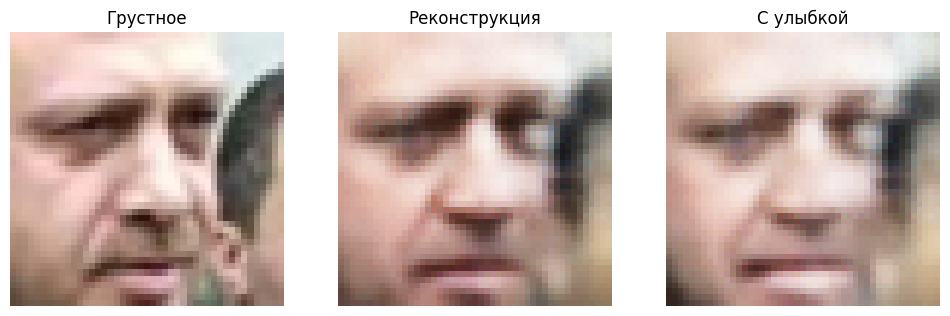

In [15]:
smiling_idx = attrs_train.index[attrs_train['Smiling'] > 0.5][:15].tolist()
neutral_idx = attrs_train.index[attrs_train['Smiling'] < -0.5][:15].tolist()

print(f'Найдено улыбающихся: {len(smiling_idx)}')
print(f'Найдено грустных: {len(neutral_idx)}')

# берем изображения по индексам
smiling_imgs = X_train[smiling_idx].to(device)
neutral_imgs = X_train[neutral_idx].to(device)

model_autoencoder.eval()

with torch.no_grad():
    _, smiling_latent = model_autoencoder(smiling_imgs)
    _, neutral_latent = model_autoencoder(neutral_imgs)
    # считаем вектор улыбки
    smile_vector = smiling_latent.mean(dim=0) - neutral_latent.mean(dim=0)
    print(f'Норма (длина) вектора улыбки: {smile_vector.norm().item():.4f}')

    # берем первого грустного
    sad_img = neutral_imgs[0:1]
    _, sad_latent = model_autoencoder(sad_img) 
    smiling_latent_new = sad_latent + smile_vector
    original_reconstruction = model_autoencoder.decoder( 
        model_autoencoder.fc_dec(sad_latent)
    )
    smiling_reconstruction = model_autoencoder.decoder(  
        model_autoencoder.fc_dec(smiling_latent_new)
    )

# numpy
sad_img_np = sad_img[0].cpu().permute(1, 2, 0).numpy()
original_np = original_reconstruction[0].cpu().permute(1, 2, 0).numpy()
smiling_np = smiling_reconstruction[0].cpu().permute(1, 2, 0).numpy()

# визуализируем
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(sad_img_np)
axes[0].set_title('Грустное')
axes[0].axis('off')

axes[1].imshow(original_np)
axes[1].set_title('Реконструкция')
axes[1].axis('off')

axes[2].imshow(smiling_np)
axes[2].set_title('С улыбкой')
axes[2].axis('off')

plt.show()

Вуаля! Вы восхитительны!

Теперь вы можете пририсовывать людям не только улыбки, но и много чего другого -- закрывать/открывать глаза, пририсовывать очки... В общем, все, на что хватит фантазии и на что есть атрибуты в `attrs`:)

# Часть 2: Variational Autoencoder (10 баллов)

Займемся обучением вариационных автоэнкодеров — проапгрейженной версии AE. Обучать будем на датасете MNIST, содержащем написанные от руки цифры от 0 до 9

In [16]:
from torchvision import datasets, transforms

batch_size = 32
# MNIST Dataset
train_dataset = datasets.MNIST(root='./mnist_data/', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = datasets.MNIST(root='./mnist_data/', train=False, transform=transforms.ToTensor(), download=False)

# Data Loader (Input Pipeline)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 41.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.16MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.99MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.32MB/s]


## 2.1 Архитектура модели и обучение (2 балла)

Реализуем VAE. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Рекомендуем пользоваться более сложными моделями, чем та, что была на семинаре:) Экспериментируйте!

In [17]:
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1),   # 28 -> 14
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),  # 14 -> 7
            nn.ReLU(),
            nn.Flatten()
        )
        self.fc_mu = nn.Linear(64 * 7 * 7, dim_code)
        self.fc_logsigma = nn.Linear(64 * 7 * 7, dim_code)

        # Decoder
        self.fc_dec = nn.Linear(dim_code, 64 * 7 * 7)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (64, 7, 7)),
            nn.ConvTranspose2d(
                64, 32, kernel_size=3, stride=2,
                padding=1, output_padding=1
            ),  
            nn.ReLU(),
            nn.ConvTranspose2d(
                32, 1, kernel_size=3, stride=2,
                padding=1, output_padding=1
            ),  
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder(x)
        mu = self.fc_mu(x)
        logsigma = self.fc_logsigma(x)
        return mu, logsigma

    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            sigma = torch.exp(logsigma)
            eps = torch.randn_like(sigma)
            z = mu + eps * sigma
            return z
        else:
            return mu

    def decode(self, z):
        x = self.fc_dec(z)
        reconstruction = self.decoder(x)
        return reconstruction

    def forward(self, x):
        mu, logsigma = self.encode(x)
        z = self.gaussian_sampler(mu, logsigma)
        reconstruction = self.decode(z)
        return mu, logsigma, reconstruction

Определим лосс и его компоненты для VAE:

Надеюсь, вы уже прочитали материал в towardsdatascience (или еще где-то) про VAE и знаете, что лосс у VAE состоит из двух частей: KL и log-likelihood.

Общий лосс будет выглядеть так:

$$\mathcal{L} = -D_{KL}(q_{\phi}(z|x)||p(z)) + \log p_{\theta}(x|z)$$

Формула для KL-дивергенции:

$$D_{KL} = -\frac{1}{2}\sum_{i=1}^{dimZ}(1+log(\sigma_i^2)-\mu_i^2-\sigma_i^2)$$

В качестве log-likelihood возьмем привычную нам кросс-энтропию.

In [18]:
def KL_divergence(mu, logsigma):
    """
    часть функции потерь, которая отвечает за "близость"
    латентных представлений разных людей
    """
    loss = -0.5 * torch.sum(1 + 2 * logsigma - mu.pow(2) - torch.exp(2 * logsigma),
        dim=1)
    return loss.mean()

def log_likelihood(x, reconstruction):
    """
    часть функции потерь, которая отвечает за качество реконструкции
    """
    loss = F.binary_cross_entropy(reconstruction, x, reduction='mean')
    return loss

def loss_vae(x, mu, logsigma, reconstruction):
    kl_loss = KL_divergence(mu, logsigma)
    recon_loss = log_likelihood(x, reconstruction)
    return kl_loss + recon_loss

И обучим модель:

Давайте посмотрим, как наш тренированный VAE кодирует и восстанавливает картинки:

Epoch [1/10] Train Loss: 0.2877 Test Loss: 0.2725
Epoch [2/10] Train Loss: 0.2659 Test Loss: 0.2665
Epoch [3/10] Train Loss: 0.2648 Test Loss: 0.2637
Epoch [4/10] Train Loss: 0.2643 Test Loss: 0.2632
Epoch [5/10] Train Loss: 0.2640 Test Loss: 0.2630
Epoch [6/10] Train Loss: 0.2639 Test Loss: 0.2627
Epoch [7/10] Train Loss: 0.2638 Test Loss: 0.2629
Epoch [8/10] Train Loss: 0.2637 Test Loss: 0.2626
Epoch [9/10] Train Loss: 0.2637 Test Loss: 0.2630
Epoch [10/10] Train Loss: 0.2636 Test Loss: 0.2628


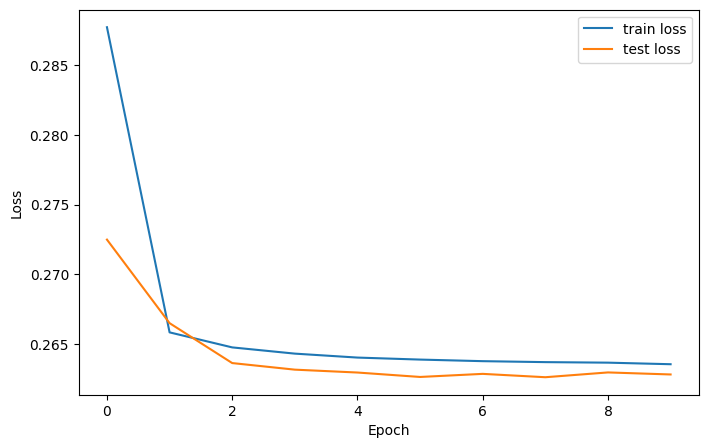

In [19]:
# определим модель
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_vae = VAE().to(device)
optimizer = optim.Adam(model_vae.parameters(), lr=1e-3)

# трейн параметры
num_epochs = 10
train_losses = []
test_losses = []

for epoch in range(num_epochs):
    # трейн
    model_vae.train()
    train_loss = 0
    
    for x, _ in train_loader:
        x = x.to(device)
        optimizer.zero_grad()
        mu, logsigma, reconstruction = model_vae(x)
        loss = loss_vae(x, mu, logsigma, reconstruction)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # валидация
    model_vae.eval()
    test_loss = 0
    
    with torch.no_grad():
        for x, _ in test_loader:
            x = x.to(device)
            mu, logsigma, reconstruction = model_vae(x)
            loss = loss_vae(x, mu, logsigma, reconstruction)
            test_loss += loss.item()
    test_loss /= len(test_loader)
    test_losses.append(test_loss)
    print(f'Epoch [{epoch+1}/{num_epochs}] '
          f'Train Loss: {train_loss:.4f} '
          f'Test Loss: {test_loss:.4f}')

# визуализируем лосс
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='train loss')
plt.plot(test_losses, label='test loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Давайте попробуем проделать для VAE то же, что и с обычным автоэнкодером -- подсунуть decoder'у из VAE случайные векторы из нормального распределения и посмотреть, какие картинки получаются:

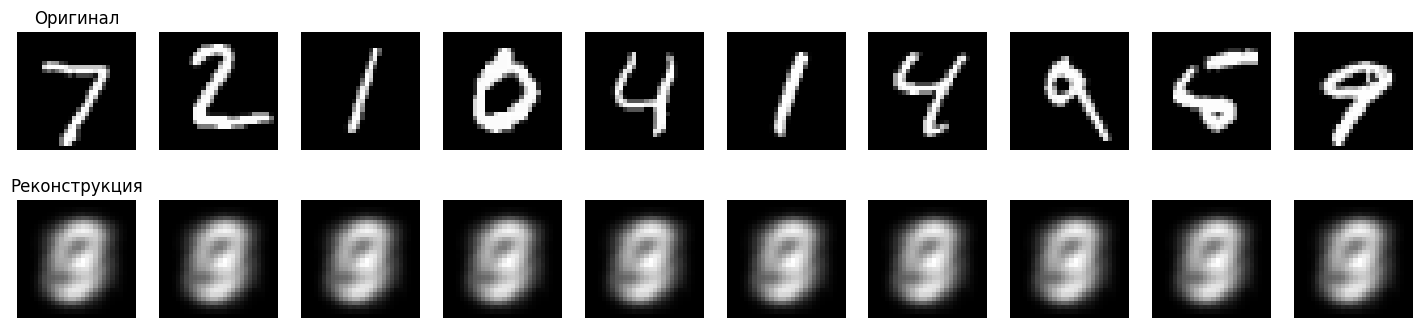

In [20]:
model_vae.eval()
with torch.no_grad():
    x, _ = next(iter(test_loader))
    x = x[:10].to(device)
    mu, logsigma, reconstruction = model_vae(x)

# to numpy
originals = x.cpu().squeeze(1).numpy()
reconstructions = reconstruction.cpu().squeeze(1).numpy()

# визуализируем
fig, axes = plt.subplots(2, 10, figsize=(18, 4))
for i in range(10):
    # original
    axes[0, i].imshow(originals[i], cmap='gray')
    axes[0, i].axis('off')
    # reconstruction
    axes[1, i].imshow(reconstructions[i], cmap='gray')
    axes[1, i].axis('off')
axes[0, 0].set_title('Оригинал')
axes[1, 0].set_title('Реконструкция')

plt.show()

## 2.2. Latent Representation (2 балла)

Давайте посмотрим, как латентные векторы картинок лиц выглядят в пространстве.
Ваша задача -- изобразить латентные векторы картинок точками в двумерном просторанстве.

Это позволит оценить, насколько плотно распределены латентные векторы изображений цифр в пространстве.

Плюс давайте сделаем такую вещь: покрасим точки, которые соответствуют картинкам каждой цифры, в свой отдельный цвет

Подсказка: красить -- это просто =) У plt.scatter есть параметр c (color), см. в документации.


Итак, план:
1. Получить латентные представления картинок тестового датасета
2. С помощтю `TSNE` (есть в `sklearn`) сжать эти представления до размерности 2 (чтобы можно было их визуализировать точками в пространстве)
3. Визуализировать полученные двумерные представления с помощью `matplotlib.scatter`, покрасить разными цветами точки, соответствующие картинкам разных цифр.

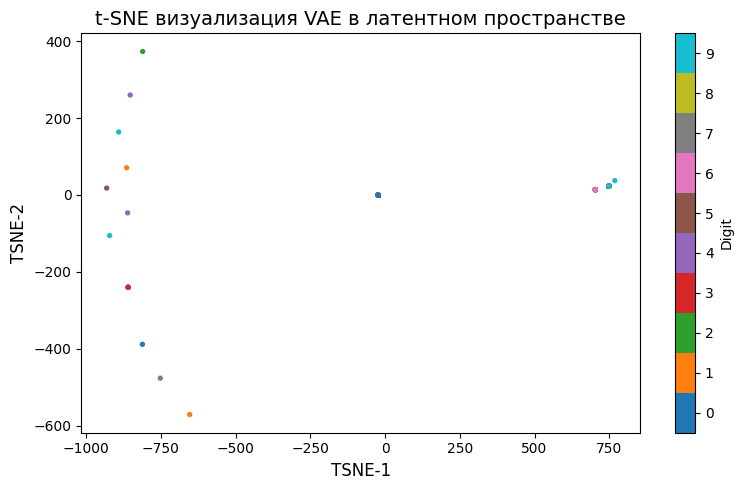

In [21]:
model_vae.eval()

latent_vectors = []
labels = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        mu, logsigma = model_vae.encode(x)
        latent_vectors.append(mu.cpu().numpy())
        labels.append(y.numpy())

# конкатенция
latent_vectors = np.concatenate(latent_vectors, axis=0)
labels = np.concatenate(labels, axis=0)

# TSNE
tsne = TSNE(n_components=2, perplexity=50, random_state=RANDOM_STATE)
latent_2d = tsne.fit_transform(latent_vectors)

# визуализация
plt.figure(figsize=(8, 5))
scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1],
                      c=labels, cmap='tab10', s=8, 
                      vmin=-0.5, vmax=9.5)  
plt.colorbar(scatter, ticks=range(10), label='Digit')
plt.title('t-SNE визуализация VAE в латентном пространстве', fontsize=14)
plt.xlabel('TSNE-1', fontsize=12)
plt.ylabel('TSNE-2', fontsize=12)
plt.tight_layout()
plt.show()

Что вы думаете о виде латентного представления?

График визуализирует латентное пространство для датасета с цифрами <br>
Каждая точка соответствует цифре из тестовой выборки.  <br>
ЦИфры далеко друг от друга, это означает, что VAE научился по-разному кодировать разные цифры

__Congrats v2.0!__

## 2.3. Conditional VAE (6 баллов)


Мы уже научились обучать обычный AE на датасете картинок и получать новые картинки, используя генерацию шума и декодер.
Давайте теперь допустим, что мы обучили AE на датасете MNIST и теперь хотим генерировать новые картинки с числами с помощью декодера (как выше мы генерили рандомные лица).
И вот нам понадобилось сгенерировать цифру 8, и мы подставляем разные варианты шума, но восьмерка никак не генерится:(

Хотелось бы добавить к нашему AE функцию "выдай мне рандомное число из вот этого вот класса", где классов десять (цифры от 0 до 9 образуют десять классов).  Conditional AE — так называется вид автоэнкодера, который предоставляет такую возможность. Ну, название "conditional" уже говорит само за себя.

И в этой части задания мы научимся такие обучать.

### Архитектура

На картинке ниже представлена архитектура простого Conditional VAE.

По сути, единственное отличие от обычного -- это то, что мы вместе с картинкой в первом слое энкодера и декодера передаем еще информацию о классе картинки.

То есть, в первый (входной) слой энкодера подается конкатенация картинки и информации о классе (например, вектора из девяти нулей и одной единицы). В первый слой декодера подается конкатенация латентного вектора и информации о классе.


![alt text](https://sun9-63.userapi.com/impg/Mh1akf7mfpNoprrSWsPOouazSmTPMazYYF49Tw/djoHNw_9KVA.jpg?size=1175x642&quality=96&sign=e88baec5f9bb91c8443fba31dcf0a4df&type=album)

![alt text](https://sun9-73.userapi.com/impg/UDuloLNKhzTBYAKewgxke5-YPsAKyGOqA-qCRg/MnyCavJidxM.jpg?size=1229x651&quality=96&sign=f2d21bfacc1c5755b76868dc4cfef39c&type=album)



На всякий случай: это VAE, то есть, latent у него все еще состоит из mu и sigma

Таким образом, при генерации новой рандомной картинки мы должны будем передать декодеру сконкатенированные латентный вектор и класс картинки.

P.S. Также можно передавать класс картинки не только в первый слой, но и в каждый слой сети. То есть на каждом слое конкатенировать выход из предыдущего слоя и информацию о классе.

In [22]:
num_classes = 10

class CVAE(nn.Module):
    def __init__(self):
        super(CVAE, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),  
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  
            nn.ReLU(),
            nn.Flatten()
        )
        self.fc_mu = nn.Linear(64 * 7 * 7 + num_classes, dim_code)
        self.fc_logsigma = nn.Linear(64 * 7 * 7 + num_classes, dim_code)

        # Decoder
        self.fc_dec = nn.Linear(dim_code + num_classes, 64 * 7 * 7)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (64, 7, 7)),
            nn.ConvTranspose2d(
                64, 32, kernel_size=3,
                stride=2, padding=1, output_padding=1), 
            nn.ReLU(),
            nn.ConvTranspose2d(
                32, 1, kernel_size=3, stride=2,
                padding=1, output_padding=1
            ),
            nn.Sigmoid()
        )

    def encode(self, x, class_num):
        x = self.encoder(x)
        class_onehot = F.one_hot(
            class_num,
            num_classes=num_classes
        ).float()
        x = torch.cat([x, class_onehot], dim=1)
        mu = self.fc_mu(x)
        logsigma = self.fc_logsigma(x)
        return mu, logsigma, class_onehot

    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            sigma = torch.exp(logsigma)
            eps = torch.randn_like(sigma)
            z = mu + eps * sigma
            return z
        else:
            return mu

    def decode(self, z, class_num):
        z = torch.cat([z, class_num], dim=1)
        x = self.fc_dec(z)
        reconstruction = self.decoder(x)
        return reconstruction

    def forward(self, x, class_num):
        mu, logsigma, class_onehot = self.encode(x, class_num)
        z = self.gaussian_sampler(mu, logsigma)
        reconstruction = self.decode(z, class_onehot)
        return mu, logsigma, reconstruction

### Sampling


Тут мы будем сэмплировать из CVAE. Это прикольнее, чем сэмплировать из простого AE/VAE: тут можно взять один и тот же латентный вектор и попросить CVAE восстановить из него картинки разных классов!
Для MNIST вы можете попросить CVAE восстановить из одного латентного вектора, например, картинки цифры 5 и 7.

Epoch [1/10] Loss: 0.2407
Epoch [2/10] Loss: 0.2243
Epoch [3/10] Loss: 0.2233
Epoch [4/10] Loss: 0.2228
Epoch [5/10] Loss: 0.2225
Epoch [6/10] Loss: 0.2223
Epoch [7/10] Loss: 0.2222
Epoch [8/10] Loss: 0.2220
Epoch [9/10] Loss: 0.2219
Epoch [10/10] Loss: 0.2218


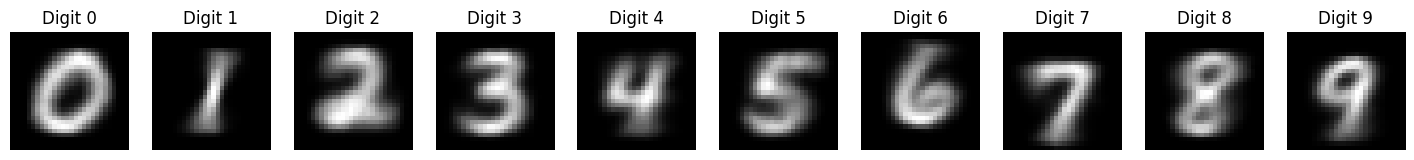

In [23]:

def loss_cvae(x, mu, logsigma, reconstruction, class_num):
    # тот же loss, что и для VAE
    kl_loss = KL_divergence(mu, logsigma)
    recon_loss = log_likelihood(x, reconstruction)
    total = recon_loss + kl_loss
    return total 

model_cvae = CVAE().to(device)
optimizer = optim.Adam(model_cvae.parameters(), lr=1e-3)

num_epochs = 10
train_losses = []

for epoch in range(num_epochs):
    model_cvae.train()
    train_loss = 0
    
    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)
        
        optimizer.zero_grad()
        mu, logsigma, reconstruction = model_cvae(x, y)
        loss = loss_cvae(x, mu, logsigma, reconstruction, y)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    print(f'Epoch [{epoch+1}/{num_epochs}] Loss: {train_loss:.4f}')


model_cvae.eval()

z = torch.randn(10, dim_code).to(device)
classes = torch.arange(0, 10).to(device)

class_onehot = F.one_hot(classes, num_classes=num_classes).float().to(device)

with torch.no_grad():
    generated = model_cvae.decode(z, class_onehot)

generated = generated.cpu().squeeze(1).numpy()

fig, axes = plt.subplots(1, 10, figsize=(18, 2))
for i in range(10):
    axes[i].imshow(generated[i], cmap='gray')
    axes[i].set_title(f"Digit {i}")
    axes[i].axis('off')
plt.show()

Splendid! Вы великолепны!


### Latent Representations

Давайте посмотрим, как выглядит латентное пространство картинок в CVAE и сравним с картинкой для VAE =)

Опять же, нужно покрасить точки в разные цвета в зависимости от класса.

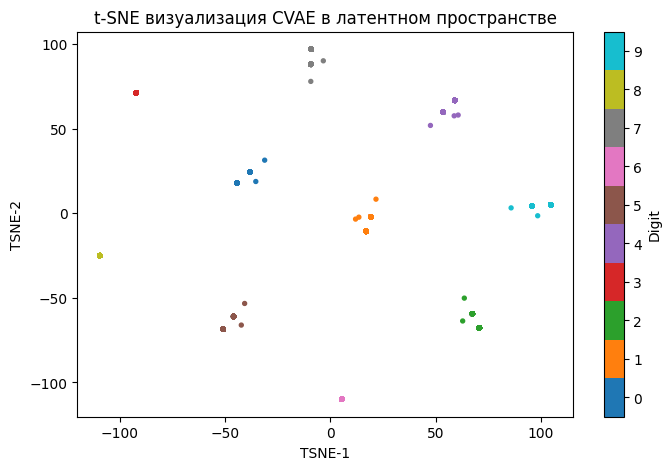

In [24]:
model_cvae.eval()

latent_vectors = []
labels = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        y = y.to(device)
        mu, logsigma, _ = model_cvae(x, y)
        latent_vectors.append(mu.cpu().numpy())
        labels.append(y.cpu().numpy())

# конкатенация
latent_vectors = np.concatenate(latent_vectors, axis=0)
labels = np.concatenate(labels, axis=0)

# TSNE
tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE)
latent_2d = tsne.fit_transform(latent_vectors)

# визуализация
plt.figure(figsize=(8, 5))
scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1],
                      c=labels, cmap='tab10', s=8, 
                      vmin=-0.5, vmax=9.5)  
plt.colorbar(scatter, ticks=range(10), label='Digit')
plt.title('t-SNE визуализация СVAE в латентном пространстве')
plt.xlabel('TSNE-1')
plt.ylabel('TSNE-2')
plt.show()

Что вы думаете насчет этой картинки? Отличается от картинки для VAE?

График `CVAE` существенно отличается от `VAE`. <br>
`VAE` сформировал один компактный кластер для каждой цифры, `CVAE` создал несколько подкластеров внутри одного класса. <br>
Это говорит о том, что `CVAE` научился различать не только цифры, но и внутренние вариации внутри каждого класса

# BONUS 1: Denoising (2 балла)



У автоэнкодеров, кроме сжатия и генерации изображений, есть другие практические применения. Про одно из них эта бонусная часть задания.

Автоэнкодеры могут быть использованы для избавления от шума на фотографиях (denoising). Для этого их нужно обучить специальным образом: input картинка будет зашумленной, а выдавать автоэнкодер должен будет картинку без шума.
То есть, loss-функция AE останется той же (MSE между реальной картинкой и выданной), а на вход автоэнкодеру будет подаваться зашумленная картинка.

<a href="https://ibb.co/YbRJ1nZ"><img src="https://i.ibb.co/0QD164t/Screen-Shot-2020-06-04-at-4-49-50-PM.png" alt="Screen-Shot-2020-06-04-at-4-49-50-PM" border="0"></a>

Для этого нужно взять ваш любимый датасет (датасет лиц из первой части этого задания или любой другой) и сделать копию этого датасета с шумом.

В питоне шум можно добавить так:

In [25]:
noise_factor = 0.5

X_noisy = X_train.numpy() + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=X_train.shape
)

X_noisy = np.clip(X_noisy, 0., 1.)

X_clean = X_train.numpy()

Epoch [1/10] Train Loss: 0.0242 Val Loss: 0.0131
Epoch [2/10] Train Loss: 0.0111 Val Loss: 0.0095
Epoch [3/10] Train Loss: 0.0088 Val Loss: 0.0080
Epoch [4/10] Train Loss: 0.0077 Val Loss: 0.0074
Epoch [5/10] Train Loss: 0.0070 Val Loss: 0.0068
Epoch [6/10] Train Loss: 0.0065 Val Loss: 0.0064
Epoch [7/10] Train Loss: 0.0062 Val Loss: 0.0063
Epoch [8/10] Train Loss: 0.0060 Val Loss: 0.0061
Epoch [9/10] Train Loss: 0.0057 Val Loss: 0.0059
Epoch [10/10] Train Loss: 0.0055 Val Loss: 0.0058


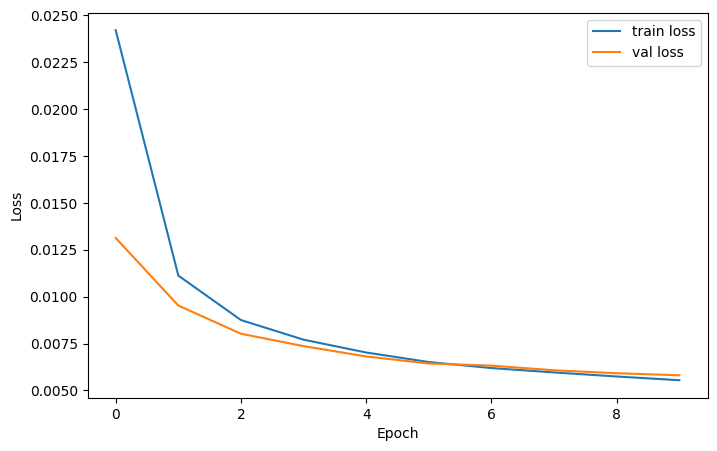

In [26]:
# сплит
X_noisy_train, X_noisy_val, X_clean_train, X_clean_val = train_test_split(
    X_noisy,
    X_clean,
    test_size=0.2,
    random_state=RANDOM_STATE
)

# в тензоры
X_noisy_train = torch.tensor(X_noisy_train, dtype=torch.float32)
X_noisy_val = torch.tensor(X_noisy_val, dtype=torch.float32)
X_clean_train = torch.tensor(X_clean_train, dtype=torch.float32)
X_clean_val = torch.tensor(X_clean_val, dtype=torch.float32)

# датасет
train_dataset = TensorDataset(X_noisy_train, X_clean_train)
val_dataset = TensorDataset(X_noisy_val, X_clean_val)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# модель
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_autoencoder = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model_autoencoder.parameters(), lr=1e-3)

num_epochs = 10
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # трейн
    model_autoencoder.train()
    train_loss = 0
    for noisy_imgs, clean_imgs in train_loader:
        noisy_imgs = noisy_imgs.to(device)
        clean_imgs = clean_imgs.to(device)
        optimizer.zero_grad()
        reconstruction, latent = model_autoencoder(noisy_imgs)
        loss = criterion(reconstruction, clean_imgs)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # валидация
    model_autoencoder.eval()
    val_loss = 0
    with torch.no_grad():
        for noisy_imgs, clean_imgs in val_loader:
            noisy_imgs = noisy_imgs.to(device)
            clean_imgs = clean_imgs.to(device)
            reconstruction, latent = model_autoencoder(noisy_imgs)
            loss = criterion(reconstruction, clean_imgs)
            val_loss += loss.item()
    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    print(f'Epoch [{epoch+1}/{num_epochs}] '
          f'Train Loss: {train_loss:.4f} '
          f'Val Loss: {val_loss:.4f}')

# кривая лосс
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='train loss')
plt.plot(val_losses, label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


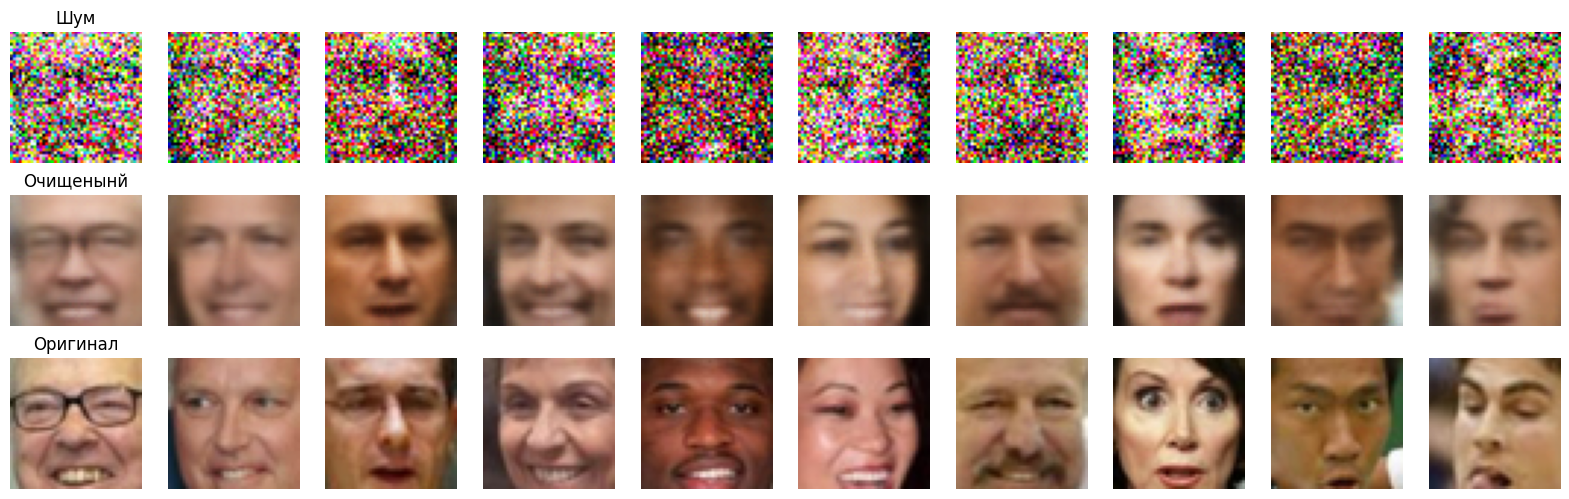

In [27]:
model_autoencoder.eval()

with torch.no_grad():
    noisy_imgs = X_noisy_val[:10].to(device)
    reconstruction, latent = model_autoencoder(noisy_imgs)

# в numpy
noisy_imgs = noisy_imgs.cpu().permute(0, 2, 3, 1).numpy()
reconstruction = reconstruction.cpu().permute(0, 2, 3, 1).numpy()
clean_imgs = X_clean_val[:10].permute(0, 2, 3, 1).numpy()

# визуализируем
fig, axes = plt.subplots(3, 10, figsize=(20, 6))
for i in range(10):
    # noisy
    axes[0, i].imshow(noisy_imgs[i])
    axes[0, i].axis('off')
    # reconstructed
    axes[1, i].imshow(reconstruction[i])
    axes[1, i].axis('off')
    # original clean
    axes[2, i].imshow(clean_imgs[i])
    axes[2, i].axis('off')
axes[0, 0].set_title('Шум')
axes[1, 0].set_title('Очищенынй')
axes[2, 0].set_title('Оригинал')
plt.show()

# BONUS 2: Image Retrieval (2 балла)



Давайте представим, что весь наш тренировочный датасет -- это большая база данных людей. И вот мы получили картинку лица какого-то человека с уличной камеры наблюдения (у нас это картинка из тестового датасета) и хотим понять, что это за человек. Что нам делать? Правильно -- берем наш VAE, кодируем картинку в латентное представление и ищем среди латентных представлений лиц нашей базы самые ближайшие!

План:

1. Получаем латентные представления всех лиц тренировочного датасета
2. Обучаем на них LSHForest `(sklearn.neighbors.LSHForest)`, например, с `n_estimators=50`
3. Берем картинку из тестового датасета, с помощью VAE получаем ее латентный вектор
4. Ищем с помощью обученного LSHForest ближайшие из латентных представлений тренировочной базы
5. Находим лица тренировочного датасета, которым соответствуют ближайшие латентные представления, визуализируем!

Немного кода вам в помощь: (feel free to delete everything and write your own)

In [28]:
# получаем латентные представления train изображений
model_autoencoder.eval()

codes = []

with torch.no_grad():
    for i in range(0, len(X_train), 64):
        batch = X_train[i:i+64].to(device)
        _, latent_code = model_autoencoder(batch) 
        codes.append(latent_code.cpu().numpy())

codes = np.concatenate(codes, axis=0)
print(f'Латентные векторы shape: {codes.shape}')
#codes = StandardScaler().fit_transform(codes)

Латентные векторы shape: (10514, 128)


In [29]:
# обучаем LSHForest
from sklearn.neighbors import NearestNeighbors
 
nn_index = NearestNeighbors(n_neighbors=11, algorithm='ball_tree').fit(codes)

In [30]:
def get_similar(image, n_neighbors=5):
    model_autoencoder.eval()  

    with torch.no_grad():
        image_batch = image.unsqueeze(0).to(device)
        _, code = model_autoencoder(image_batch) 
        code = code.cpu().numpy()
    distances, indices = nn_index.kneighbors(code, n_neighbors=n_neighbors)
    return distances[0], X_train[indices[0]]

In [31]:
def show_similar(image):
    distances, neighbors = get_similar(image, n_neighbors=11)
    plt.figure(figsize=[8, 6])
    plt.subplot(3, 4, 1)
    plt.imshow(image.cpu().numpy().transpose([1, 2, 0]))
    plt.title('Оригинал')
    plt.axis('off')

    for i in range(11):
        plt.subplot(3, 4, i + 2)
        plt.imshow(neighbors[i].cpu().numpy().transpose([1, 2, 0]))
        plt.title('Расстояние=%.3f' % distances[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

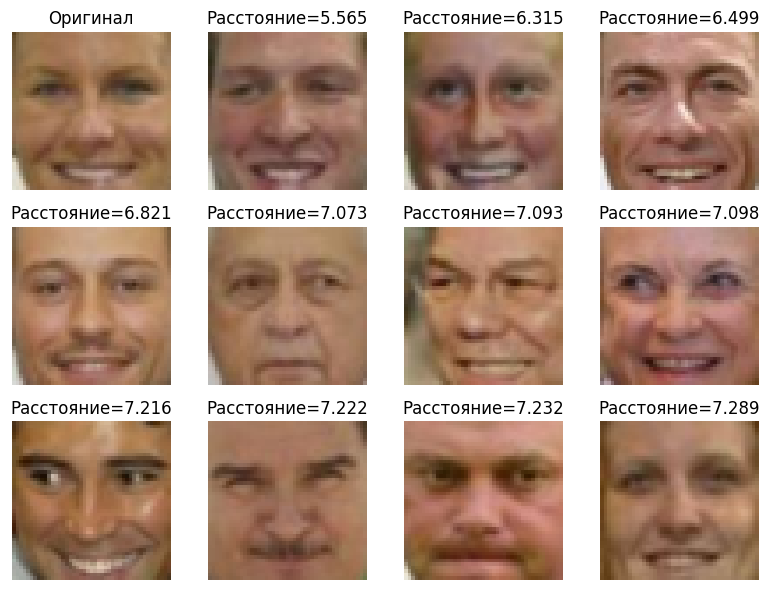

In [32]:
# пример поиска похожих лиц
test_image = X_val[0]
show_similar(test_image)